In [2]:
import get_ps_21cmEMU
import numpy as np
from getdist import MCSamples, plots
import torch
_ = torch.manual_seed(0)
import matplotlib.pyplot as plt
# plt.style.use('sty.mplstyle')

In [3]:
# calling the emulator and getting the 1D power spectrum training data set

redshift_value = 8.01
# fiducial parameters for the emulator
log_f_star10 = -1.2
alpha_star = 0.5
t_star = 0.55
log_f_esc10 = -1.3
alpha_esc = 0
log_f_star7_mini = -2.5
log_f_esc7_mini = -1.5
log_l_x = 40.0
log_l_x_mini = 41.5
nu_x_thresh = 500
sigma_8 = 0.8118


astro_params = {"F_STAR10": log_f_star10, 
          'ALPHA_STAR': alpha_star,
          't_STAR': t_star,
          'F_ESC10': log_f_esc10,
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }

ps_1_d = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
noise_sigma = np.load("data/sigma_pk_z8.01_108_hours.npy")


def get_traning_data(theta, num_simulations):
    "first varying only three parameters: F_STAR10, F_ESC10, ALPHA_STAR"
    f_star_10 = theta[:, 0]
    f_esc_10 = theta[:, 1]
    alpha_star = theta[:, 2]
    # print(f_star_10, f_esc_10, alpha_star)

    ps_data = np.zeros((num_simulations, 32))

    for i in range(num_simulations):
        astro_params = {"F_STAR10": f_star_10[i], 
          'ALPHA_STAR': alpha_star[i],
          't_STAR': t_star,
          'F_ESC10': f_esc_10[i],
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }
        ps = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
        # noise_sigma = 0.05 * ps # 5% noise level
        # noise_sigma = 0.2 * ps # 5% noise level

        np.random.seed(i)  # for reproducibility
        ps_noisy = ps + np.random.normal(0, noise_sigma, size=ps.shape) # add noise to the power spectrum
        ps_data[i, :] = ps_noisy
        
    return ps_data

In [4]:
# defining the parameter space for training data generation
from sbi.utils import BoxUniform
lower_bounds = np.array([-2.0, -3.0, 0.0])  # lower bounds for F_STAR10, F_ESC10, ALPHA_STAR
upper_bounds = np.array([-0.5, 0.0, 1.0])  # upper bounds for F_STAR10, F_ESC10, ALPHA_STAR
prior = BoxUniform(low=torch.tensor(lower_bounds), high=torch.tensor(upper_bounds))


2026-08-01 09:02:55.385992: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-01 09:02:55.444500: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/leon/anaconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
# choosing the sbi method for inference: NPE
from sbi.inference import NPE
inference = NPE(prior=prior)

In [6]:
# creating the training data set
num_simulations = 10000
theta = prior.sample((num_simulations,))
x = get_traning_data(theta, num_simulations)
x_torch = torch.tensor(x, dtype=torch.float32)

In [ ]:
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/ps_training_data_f_star10_f_esc10_alpha_star.npy', x)
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/theta_training_data_f_star10_f_esc10_alpha_star.npy', theta)

# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/ps_training_data_f_star10_f_esc10_alpha_star_10_per_error.npy', x)
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/theta_training_data_f_star10_f_esc10_alpha_star_10_per_error.npy', theta)

In [ ]:
# np.save('data/ps_training_data_f_star10_f_esc10_alpha_star_ska_108_num_simulations_10000.npy', x)
# np.save('data/theta_training_data_f_star10_f_esc10_alpha_star_ska_108_num_simulations_10000.npy', theta)

In [8]:
# training the density estimator with the training data set
inference = inference.append_simulations(theta, x_torch)
density_estimator = inference.train()

 Neural network successfully converged after 80 epochs.

In [9]:
posterior = inference.build_posterior()
print(posterior)


Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [10]:
ps_obs = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value) # test data for inference
ps_obs_torch = torch.tensor(ps_obs, dtype=torch.float32)

In [11]:
posterior_samples = posterior.sample((1000,), x=ps_obs_torch) # draw 1000 posterior samples

  0%|          | 0/1000 [00:00<?, ?it/s]

Removed no burn in


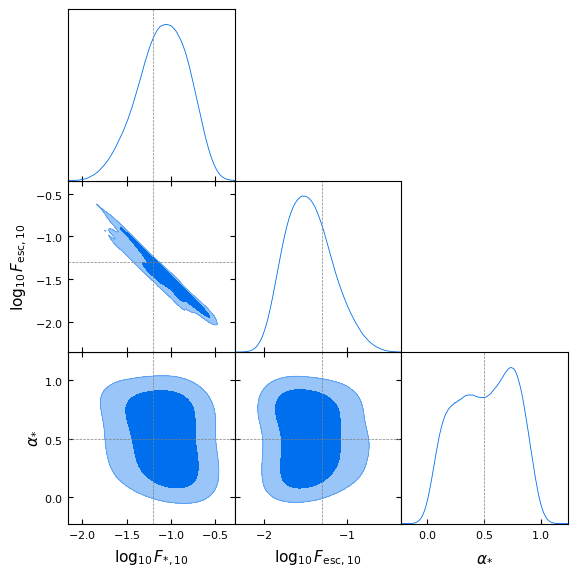

In [12]:
labels = [r'\log_{10} F_{*,10}', r'\log_{10} F_{\rm esc,10}', r'\alpha_{*}']
names = ['F_STAR10', 'F_ESC10', 'ALPHA_STAR']
true_params = [log_f_star10, log_f_esc10, alpha_star]

samples = MCSamples(
    samples=posterior_samples.numpy(), 
    names=names,
    labels=labels
)

# dictionary mapping the parameter names to their true values
markers_dict = {name: val for name, val in zip(names, true_params)}

g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True, markers=markers_dict)

In [13]:
f_star_100_samples = theta[:100, 0].numpy() 
f_esc_100_samples = theta[:100, 1].numpy()  
alpha_star_samples = theta[:100, 2].numpy() 

### Posterior Predictive Checks

In [14]:
theta_posterior_ppc = posterior.sample((200,), x=ps_obs_torch) # draw 1000 posterior samples for posterior predictive check
x_predictive = get_traning_data(theta_posterior_ppc, 200) # generate predictive data from the posterior samples

  0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
x_predictive = torch.tensor(x_predictive, dtype=torch.float32)

In [16]:
x_predictive_mean = torch.mean(x_predictive, axis=0)
print("Posterior predictives: ", x_predictive_mean)

Posterior predictives:  tensor([ 0.7720,  0.9423,  1.0688,  1.2666,  1.8186,  2.1924,  2.5524,  3.1169,
         3.7818,  4.9611,  6.1493,  6.9186,  8.1103,  9.5631, 10.3463, 11.4902,
        12.3243, 13.2137, 13.4868, 14.0145, 13.3885, 13.9307, 14.5064, 14.6602,
        13.5545, 13.8847, 15.6021, 16.5101, 18.7096, 18.5569, 14.5763, 23.3677])


In [17]:
print("Posterior predictives: ", torch.mean(x_predictive, axis=0))
print("Observation: ", ps_obs_torch)

Posterior predictives:  tensor([ 0.7720,  0.9423,  1.0688,  1.2666,  1.8186,  2.1924,  2.5524,  3.1169,
         3.7818,  4.9611,  6.1493,  6.9186,  8.1103,  9.5631, 10.3463, 11.4902,
        12.3243, 13.2137, 13.4868, 14.0145, 13.3885, 13.9307, 14.5064, 14.6602,
        13.5545, 13.8847, 15.6021, 16.5101, 18.7096, 18.5569, 14.5763, 23.3677])
Observation:  tensor([ 0.7267,  0.8725,  1.0716,  1.3829,  1.7754,  2.2216,  2.6792,  3.1790,
         3.9450,  5.0543,  6.2081,  7.0598,  8.2393,  9.6616, 10.3930, 11.6466,
        12.2580, 12.8784, 13.3806, 13.5096, 13.7860, 13.7788, 13.7720, 13.8290,
        13.7985, 13.9446, 14.1628, 14.5241, 15.1523, 16.0108, 17.6353, 20.4024])


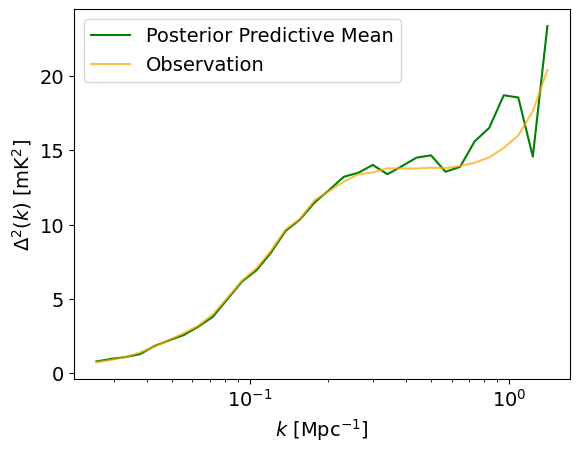

In [18]:
k_values = np.load('/home/leon/Documents/codes/sbi_21cm_ps/data/k_values.npy')
plt.plot(k_values, torch.mean(x_predictive, axis=0), label='Posterior Predictive Mean', color='green')
# plt.errorbar(k_values, torch.mean(x_predictive, axis=0), yerr=torch.std(x_predictive, axis=0), color='green', alpha=0.5, label='Posterior Predictive Std Dev')
plt.plot(k_values, ps_obs_torch, label='Observation', color='orange', alpha=0.7)
plt.xscale('log')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$\Delta^2(k)$ [mK$^2$]')
plt.legend()
plt.show()

### Simulation-Based Calibration (SBC)

In [19]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

# Obtain your `posterior_estimator` with NPE, NLE, NRE.
posterior = inference.build_posterior()

num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s
prior_samples = prior.sample((num_sbc_samples,))
prior_predictives = get_traning_data(prior_samples, num_sbc_samples)  # generate predictive data from the prior samples


Sampling 200 times (1000,) posterior samples.: 100%|██████████| 200/200 [00:30<00:00,  6.50it/s]


Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

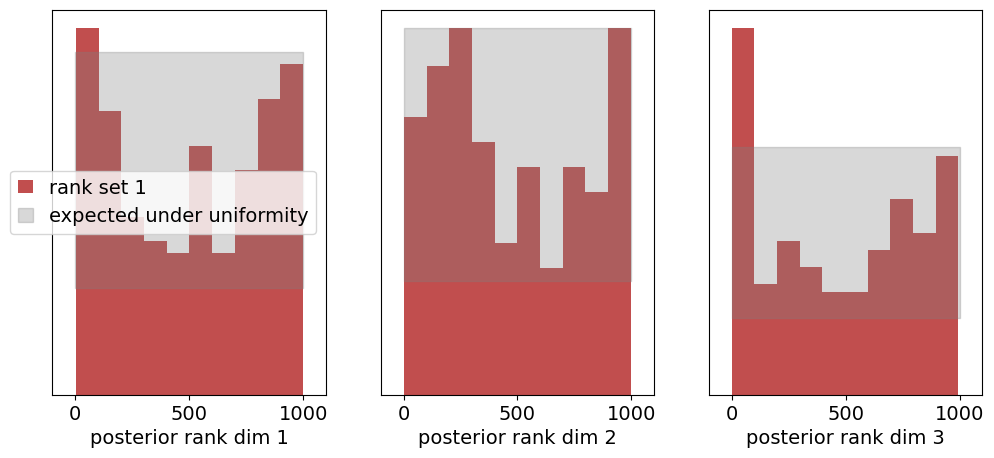

In [20]:

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples = 1_000
ranks, dap_samples = run_sbc(
    prior_samples,
    torch.tensor(prior_predictives, dtype=torch.float32),
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
# fig, ax = sbc_rank_plot(
#     ranks,
#     num_posterior_samples,
#     num_bins=20,
#     figsize=(5, 3),
# )
fig, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  
)